In [35]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from skimage.color import rgb2gray
import cv2
import numpy as np

In [36]:
image_dir = 'images'
masks_dir = 'masks'

# test ảnh

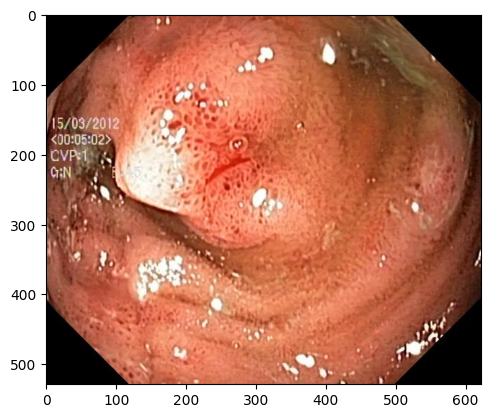

In [37]:
img = cv2.imread('images/cju0qkwl35piu0993l0dewei2.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

# load data

In [38]:
def load_kavsir_data(image_dir,masks_dir, image_size = (256,256)):
    images =[]
    masks = []
    for image_name in os.listdir(image_dir):
        img_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(masks_dir, image_name)

        img = cv2.imread(img_path)
        img = cv2.resize(img, image_size)
        img = img/255.0 # Normalize

        mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, image_size)
        mask = mask/255.0  # Normalize
        
        mask = np.expand_dims(mask, axis=-1)
        images.append(img)
        masks.append(mask)
    images = np.array(images)
    masks = np.array(masks)
    return images, masks


In [39]:
# upload data
X,Y = load_kavsir_data(image_dir, masks_dir)


In [40]:
# chia dữ liệu 
# 60% training , 40% validation + testing
X_train, X_val_test, Y_train, Y_val_test = train_test_split(X,Y, test_size= 0.4, random_state= 50)


# 50% validation với 50% testing
X_val, X_test, Y_val, Y_test = train_test_split(X_val_test, Y_val_test, test_size= 0.5, random_state=50)

#print size
print(f"training set: {X_train.shape}, {Y_train.shape}")
print(f"Validation set: {X_val.shape},{Y_val.shape}")
print(f"Test set :{X_test.shape}, {Y_test.shape}")

training set: (600, 256, 256, 3), (600, 256, 256, 1)
Validation set: (200, 256, 256, 3),(200, 256, 256, 1)
Test set :(200, 256, 256, 3), (200, 256, 256, 1)


In [41]:
# Chuyển sang ảnh xám
X_train_gray = np.expand_dims(np.array([rgb2gray(img) for img in X_train]),axis=-1)
X_val_gray = np.expand_dims(np.array([rgb2gray(img) for img in X_val]),axis=-1)
X_test_gray = np.expand_dims(np.array([rgb2gray(img) for img in X_test]),axis=-1)

# Định nghĩa mô hình Unet

In [42]:
def Unet_model(input_size=(256,256,1)):
    inputs = tf.keras.layers.Input(input_size)

    # Encoder
    c1 = tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='same')(inputs)
    c1 =tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2,2))(c1)

    c2 = tf.keras.layers.Conv2D(128,(3,3),activation='relu',padding='same')(p1)
    c2 =tf.keras.layers.Conv2D(128,(3,3),activation='relu',padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2,2))(c2)

    c3 = tf.keras.layers.Conv2D(256,(3,3),activation='relu',padding='same')(p2)
    c3 =tf.keras.layers.Conv2D(256,(3,3),activation='relu',padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2,2))(c3)

    c4 = tf.keras.layers.Conv2D(512,(3,3),activation='relu',padding='same')(p3)
    c4 =tf.keras.layers.Conv2D(512,(3,3),activation='relu',padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D((2,2))(c4)


    # Bottleneck
    c5 = tf.keras.layers.Conv2D(1024,(3,3),activation='relu',padding='same')(p4)
    c5 =tf.keras.layers.Conv2D(1024,(3,3),activation='relu',padding='same')(c5)

    # Decoder
    u6 = tf.keras.layers.Convolution2DTranspose(512,(2,2), strides=(2,2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6,c4])
    c6 = tf.keras.layers.Conv2D(512,(3,3), activation='relu',  padding='same')(u6)
    c6 = tf.keras.layers.Conv2D(512,(3,3), activation='relu', padding='same')(c6)

    u7 = tf.keras.layers.Convolution2DTranspose(256,(2,2), strides=(2,2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7,c3])
    c7 = tf.keras.layers.Conv2D(256,(3,3), activation='relu', padding='same')(u7)
    c7 = tf.keras.layers.Conv2D(256,(3,3), activation='relu',  padding='same')(c7)

    u8 = tf.keras.layers.Convolution2DTranspose(128,(2,2), strides=(2,2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8,c2])
    c8 = tf.keras.layers.Conv2D(128,(3,3), activation='relu', padding='same')(u8)
    c8 = tf.keras.layers.Conv2D(128,(3,3), activation='relu',  padding='same')(c8)

    u9 = tf.keras.layers.Convolution2DTranspose(64,(2,2), strides=(2,2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9,c1])
    c9 = tf.keras.layers.Conv2D(64,(3,3), activation='relu',  padding='same')(u9)
    c9 = tf.keras.layers.Conv2D(64,(3,3), activation='relu',  padding='same')(c9)


    outputs = tf.keras.layers.Conv2D(1,(1,1),activation='sigmoid')(c9)
    model = tf.keras.models.Model(inputs =inputs, outputs = outputs)
    return model




## Biên dịch mô hình

In [43]:
unet = Unet_model()
unet.compile(optimizer='adam', loss='binary_crossentropy',metrics= ['accuracy'])


In [44]:
# check và lưu trọng số training

model_checkpoint_dir = 'model'
os.makedirs(model_checkpoint_dir, exist_ok= True)
model_checkpoint_path = os.path.join(model_checkpoint_dir, 'best_unet_model.h5')

In [45]:
# định nghĩa modelcheckpoint_ callback
check_point = tf.keras.callbacks.ModelCheckpoint(
    model_checkpoint_path,
    monitor= 'val_loss',
    save_best_only= True,
    mode ='min',
    verbose=1 
)

In [46]:
# Huấn luyện mô hình và đánh giá mô hình
history = unet.fit(
    X_train_gray, Y_train,
    epochs= 50,
    batch_size= 3,
    validation_data= (X_val_gray, Y_val),
    callbacks=[check_point]
)
# đánh giá mô hình
loss, accuracy = unet.evaluate(X_test_gray, Y_test, batch_size=1)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')
# vẽ giá trị training và đánh giá mô hình

plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Eporch')
plt.ylabel('Accuracy')
plt.legend(['train','validation'],loc ='upper left')
plt.grid(True)
plt.show()

# save plot
plt.savefig('train_val_acc.png')

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8235 - loss: 0.5103
Epoch 1: val_loss improved from None to 0.38184, saving model to model\best_unet_model.h5



Epoch 1: finished saving model to model\best_unet_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 2063s 10s/step - accuracy: 0.8405 - loss: 0.4386 - val_accuracy: 0.8343 - val_loss: 0.3818
Epoch 2/50
 61/200 ━━━━━━━━━━━━━━━━━━━━ 21:15 9s/step - accuracy: 0.8465 - loss: 0.3647

KeyboardInterrupt: 

In [ ]:
# ví dụ minh họa kết quả test
preds = unet.predict(X_test_gray[:10])
for i in range(10):
    plt.figure(figsize=(10,5))
    plt.subplot(1,3,1)
    plt.imshow(X_test_gray[i].squeeze(), cmap= 'gray')
    plt.title('input img')

    plt.subplot(1,3,2)
    plt.imshow(Y_test[i].sequeeze(), cmap ='gray')
    plt.title('Grouth truth')

    plt.subplot(1,3,3)
    plt.imshow(preds[i].sequeeze(), cmap ='gray')
    plt.title('Prediction')